In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"
DATA_RAW = DATA_DIR / "raw"
PROCESSED = DATA_DIR / "processed"

In [22]:
df = pd.read_csv(PROCESSED / "train_collection.csv", index_col=0)
df.head()

,carat,cut,color,clarity,depth,table,x,y,z,price
id,,,,,,,,,,
0,1.52,Premium,F,VS2,62.2,58.0,7.27,7.33,4.55,13619
1,2.03,Very Good,J,SI2,62.0,58.0,8.06,8.12,5.05,13387
2,0.70,Ideal,G,VS1,61.2,57.0,5.69,5.73,3.50,2772
3,0.32,Ideal,G,VS1,61.6,56.0,4.38,4.41,2.71,666
4,1.70,Premium,G,VS2,62.6,59.0,7.65,7.61,4.77,14453


In [23]:
print('number rows', df.shape[0])
print('number columns', df.shape[1])

number rows 193573
number columns 10


In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 193573 entries, 0 to 193572
Data columns (total 10 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   carat    193573 non-null  float64
 1   cut      193573 non-null  str    
 2   color    193573 non-null  str    
 3   clarity  193573 non-null  str    
 4   depth    193573 non-null  float64
 5   table    193573 non-null  float64
 6   x        193573 non-null  float64
 7   y        193573 non-null  float64
 8   z        193573 non-null  float64
 9   price    193573 non-null  int64  
dtypes: float64(6), int64(1), str(3)
memory usage: 16.7 MB


In [25]:
category_feature=df.columns[df.dtypes=="object"]
number_feature=df.columns[df.dtypes!="object"]

In [26]:
number_feature = df.select_dtypes(
    include=["int64","float64"]
).columns

category_feature = df.select_dtypes(
    include=["object", "category"]
).columns
print("number feature")
print(list(number_feature))
print("category feature")
print(list(category_feature))

number feature
['carat', 'depth', 'table', 'x', 'y', 'z', 'price']
category feature
['cut', 'color', 'clarity']


C:\Users\nghah\AppData\Local\Temp\ipykernel_3880\1857386985.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  category_feature = df.select_dtypes(


In [27]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing

Series([], dtype: int64)

In [28]:
print("number duplicate: ",df.duplicated().sum())

number duplicate:  0


In [29]:
df["price"].describe(include="all")

count    193573.000000
mean       3969.155414
std        4034.374138
min         326.000000
25%         951.000000
50%        2401.000000
75%        5408.000000
max       18818.000000
Name: price, dtype: float64

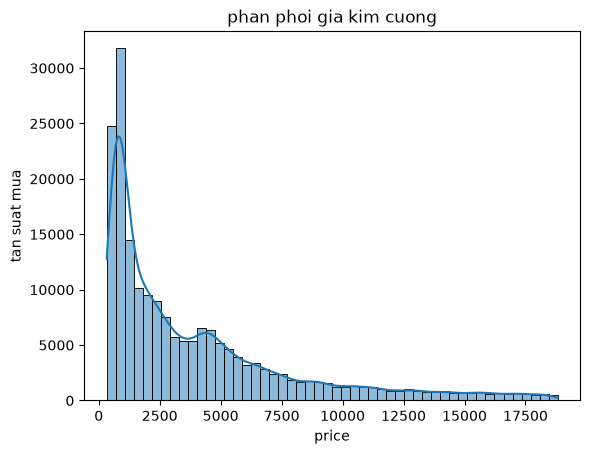

In [30]:
plt.Figure(figsize=(10, 6))
sns.histplot(
    data = df,
    x="price",
    bins=50,
    kde=True
)
plt.title('phan phoi gia kim cuong')
plt.xlabel('price')
plt.ylabel('tan suat mua')
plt.show()

In [31]:
df[number_feature].describe()

,carat,depth,table,x,y,z,price
count,193573.000000,193573.000000,193573.000000,193573.000000,193573.000000,193573.000000,193573.000000
mean,0.790688,61.820574,57.227675,5.715312,5.720094,3.534246,3969.155414
std,0.462688,1.081704,1.918844,1.109422,1.102333,0.688922,4034.374138
min,0.200000,52.100000,49.000000,0.000000,0.000000,0.000000,326.000000
25%,0.400000,61.300000,56.000000,4.700000,4.710000,2.900000,951.000000
50%,0.700000,61.900000,57.000000,5.700000,5.720000,3.530000,2401.000000
75%,1.030000,62.400000,58.000000,6.510000,6.510000,4.030000,5408.000000
max,3.500000,71.600000,79.000000,9.650000,10.010000,31.300000,18818.000000


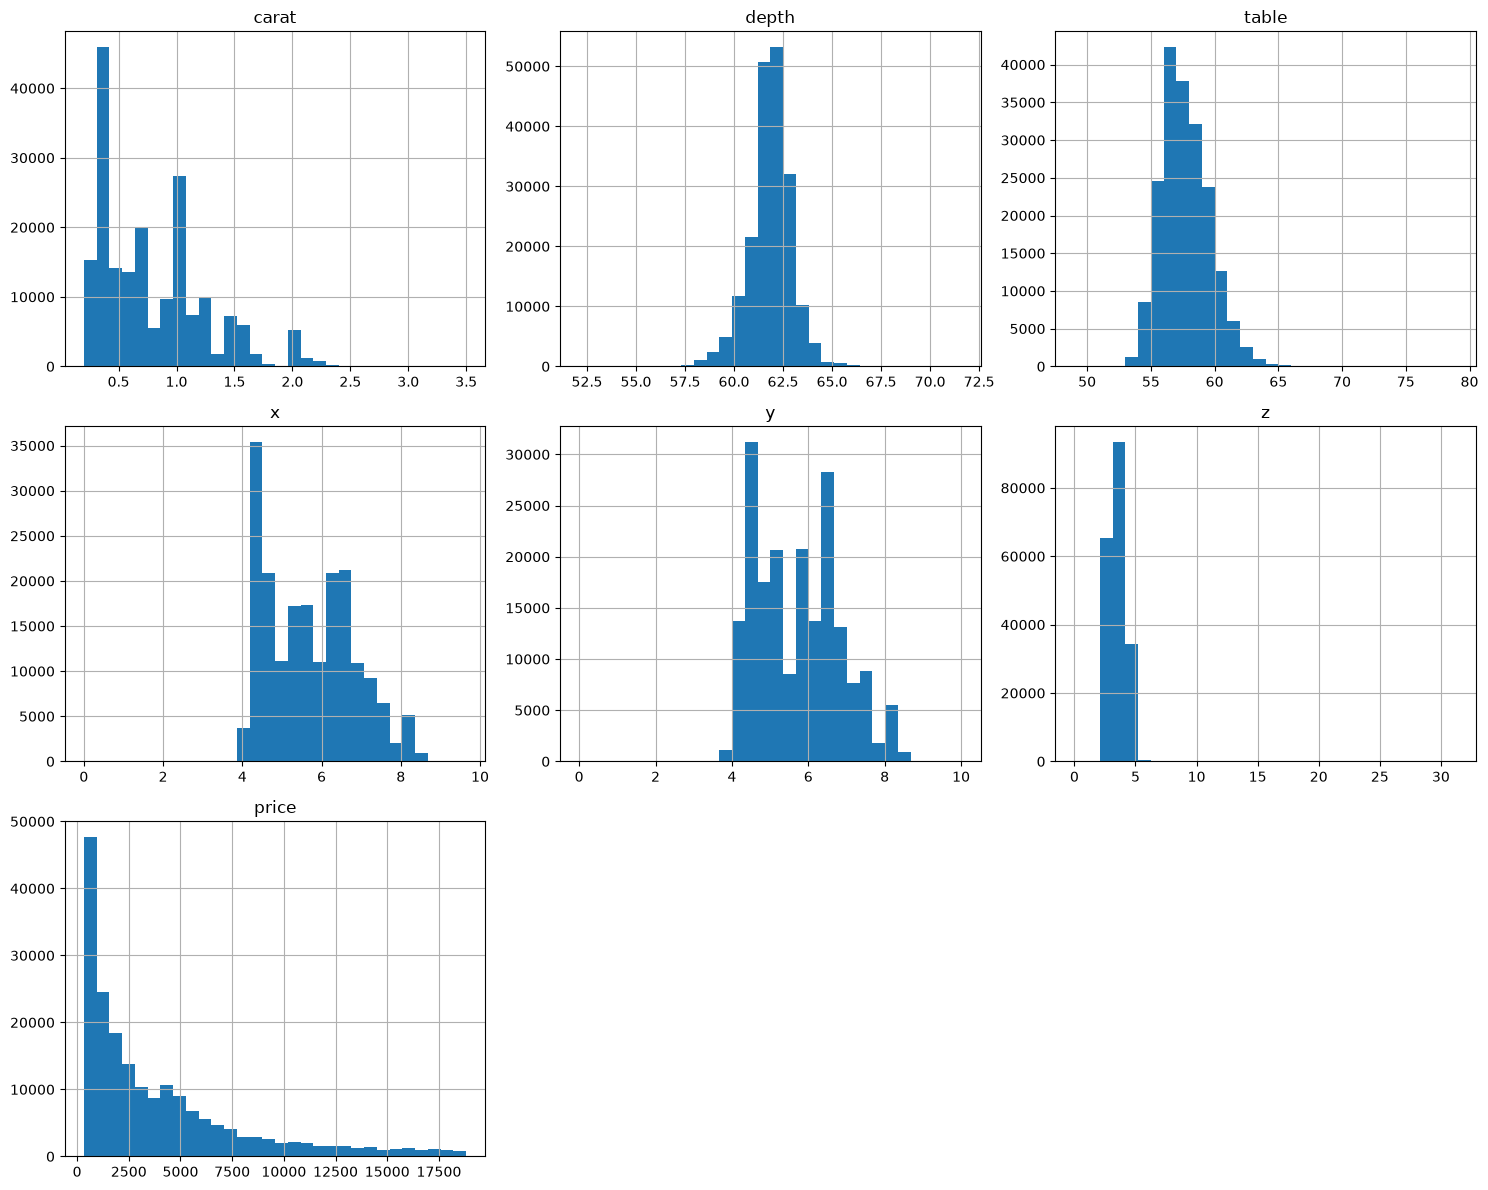

In [32]:
df[number_feature
   ].hist(
    figsize=(15, 12),
    bins=30
)

plt.tight_layout()
plt.show()

In [33]:
for cols in category_feature:
    print("\n {cols}")
    print(df[cols].value_counts)


 {cols}
<bound method IndexOpsMixin.value_counts of id
0           Premium
1         Very Good
2             Ideal
3             Ideal
4           Premium
            ...    
193568        Ideal
193569      Premium
193570    Very Good
193571    Very Good
193572         Good
Name: cut, Length: 193573, dtype: str>

 {cols}
<bound method IndexOpsMixin.value_counts of id
0         F
1         J
2         G
3         G
4         G
         ..
193568    D
193569    G
193570    F
193571    D
193572    E
Name: color, Length: 193573, dtype: str>

 {cols}
<bound method IndexOpsMixin.value_counts of id
0          VS2
1          SI2
2          VS1
3          VS1
4          VS2
          ... 
193568    VVS2
193569    VVS2
193570     SI1
193571     SI1
193572     SI2
Name: clarity, Length: 193573, dtype: str>


In [42]:
df[category_feature]["cut"].value_counts

<bound method IndexOpsMixin.value_counts of id
0           Premium
1         Very Good
2             Ideal
3             Ideal
4           Premium
            ...    
193568        Ideal
193569      Premium
193570    Very Good
193571    Very Good
193572         Good
Name: cut, Length: 193573, dtype: str>

In [43]:
df[category_feature]["color"].value_counts

<bound method IndexOpsMixin.value_counts of id
0         F
1         J
2         G
3         G
4         G
         ..
193568    D
193569    G
193570    F
193571    D
193572    E
Name: color, Length: 193573, dtype: str>

In [44]:
df[category_feature]["clarity"].value_counts

<bound method IndexOpsMixin.value_counts of id
0          VS2
1          SI2
2          VS1
3          VS1
4          VS2
          ... 
193568    VVS2
193569    VVS2
193570     SI1
193571     SI1
193572     SI2
Name: clarity, Length: 193573, dtype: str>

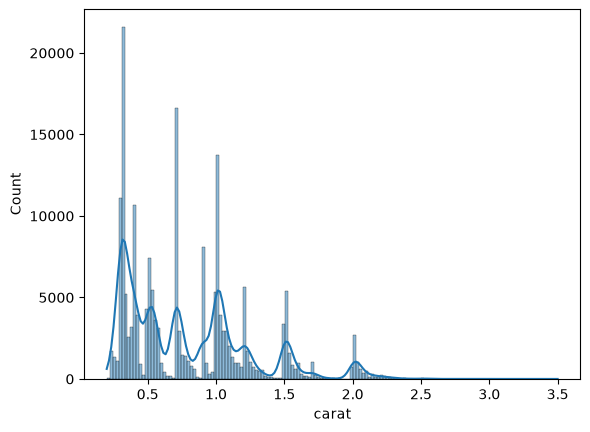

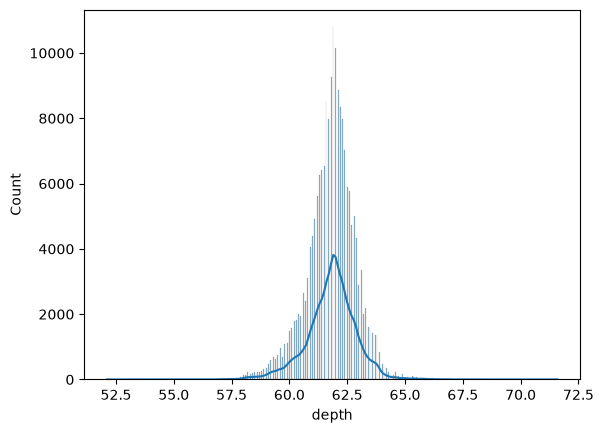

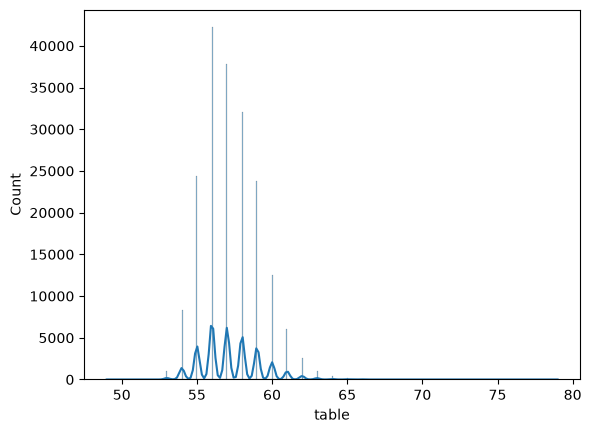

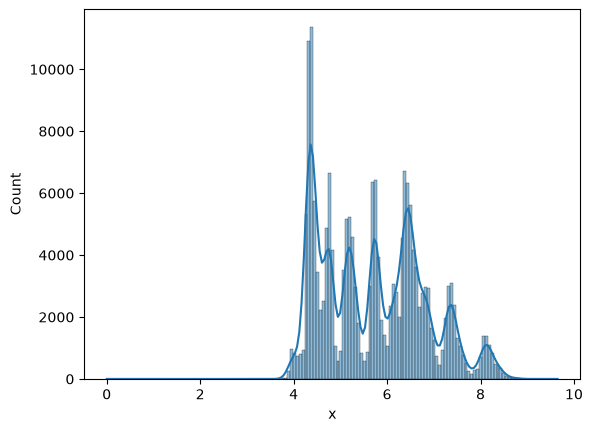

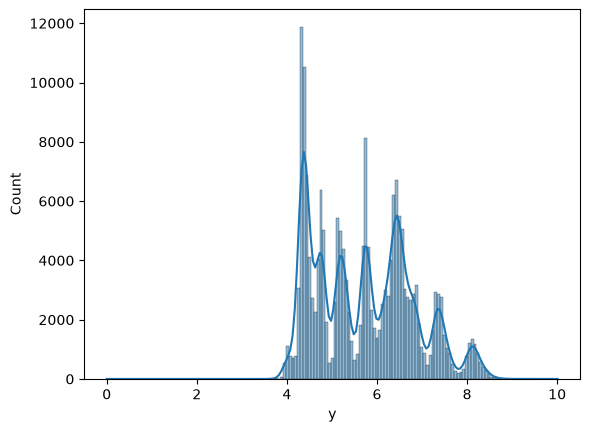

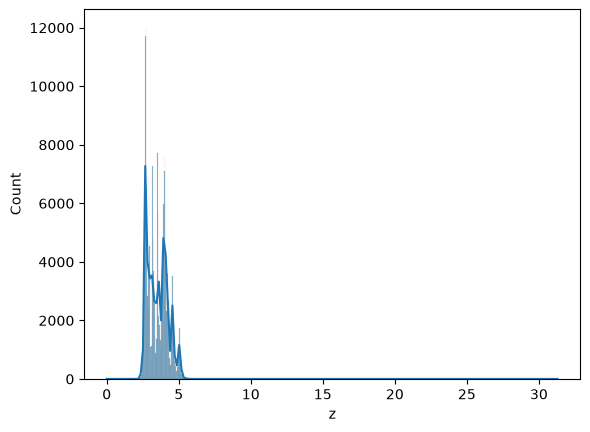

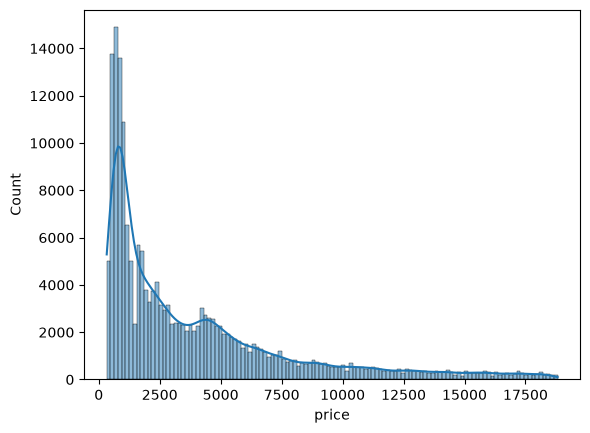

In [45]:
plt.Figure(figsize=(6,4))
for col in number_feature:
    sns.histplot(data=df, x=col,kde=True)
    print("\n")
    plt.show()

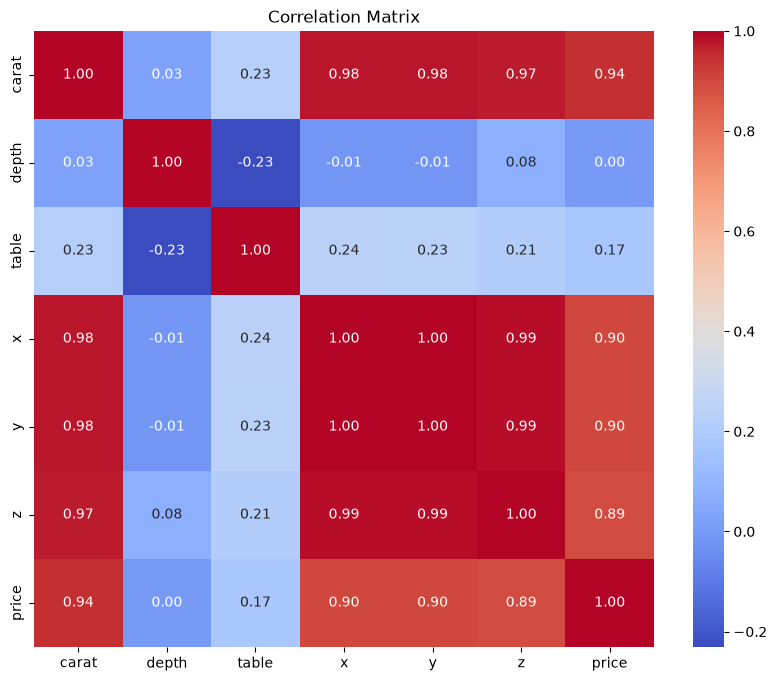

In [37]:
correlation = df[number_feature].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

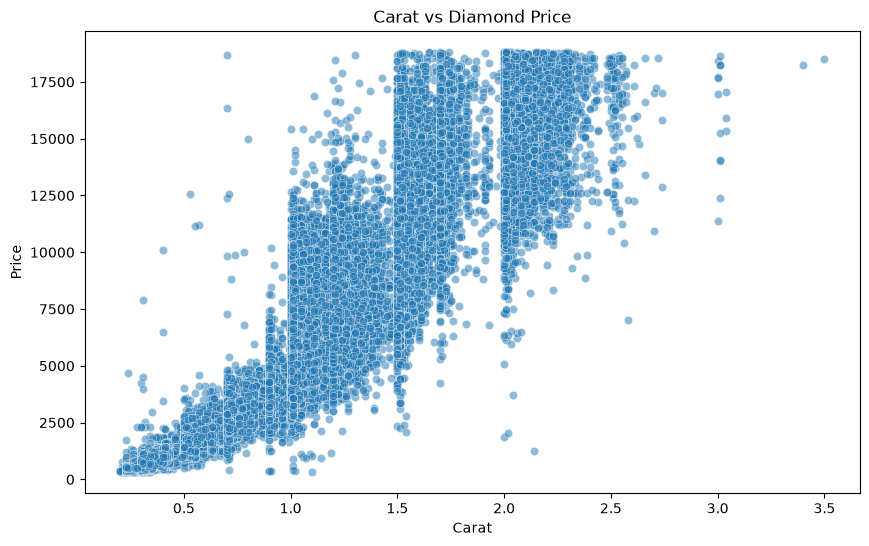

In [38]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="carat",
    y="price",
    alpha=0.5
)

plt.title("Carat vs Diamond Price")
plt.xlabel("Carat")
plt.ylabel("Price")

plt.show()

In [46]:
df.columns

Index(['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'x', 'y', 'z',
       'price'],
      dtype='str')

In [47]:
df["clarity"].unique()

<ArrowStringArray>
['VS2', 'SI2', 'VS1', 'SI1', 'IF', 'VVS2', 'VVS1', 'I1']
Length: 8, dtype: str

In [48]:
df["cut"].unique()

<ArrowStringArray>
['Premium', 'Very Good', 'Ideal', 'Good', 'Fair']
Length: 5, dtype: str

In [49]:
df["color"].unique()

<ArrowStringArray>
['F', 'J', 'G', 'E', 'D', 'H', 'I']
Length: 7, dtype: str

In [50]:
cut_map={"Fair":1,"Good":2,"Very Good":3,"Premium":4,"Ideal":5}
clarity_map = {"I1":1,"SI2":2 ,"SI1":3 ,"VS2":4 , "VS1":5 , "VVS2":6 , "VVS1":7 ,"IF":8}
color_map = {"D":1 ,"E":2 ,"F":3 , "G":4 ,"H":5 , "I":6, "J":7}

In [52]:
df["cut"]=df["cut"].map(cut_map)
df["clarity"]=df["clarity"].map(clarity_map)
df["color"]=df["color"].map(color_map)

In [56]:
df

,carat,cut,color,clarity,depth,table,x,y,z,price
id,,,,,,,,,,
0,1.52,4,3,4,62.2,58.0,7.27,7.33,4.55,13619
1,2.03,3,7,2,62.0,58.0,8.06,8.12,5.05,13387
2,0.70,5,4,5,61.2,57.0,5.69,5.73,3.50,2772
3,0.32,5,4,5,61.6,56.0,4.38,4.41,2.71,666
4,1.70,4,4,4,62.6,59.0,7.65,7.61,4.77,14453
...,...,...,...,...,...,...,...,...,...,...
193568,0.31,5,1,6,61.1,56.0,4.35,4.39,2.67,1130
193569,0.70,4,4,6,60.3,58.0,5.75,5.77,3.47,2874
193570,0.73,3,3,3,63.1,57.0,5.72,5.75,3.62,3036


In [57]:
PROCESSED.mkdir(parents=True, exist_ok=True)
df.to_csv(PROCESSED / "train_EDA.csv", index=False)

## EDA Summary

### Key Findings

1. The target variable `price` is lệch phải
2. The `carat` feature shows a very strong positive
3. Categorical features such as `cut`, `color`, and `clarity` Các boxplot chồng lấn nhau nhiều và có rất nhiều outlier giá cao
4. Some features contain  `x`, `y`, `z` have a minimum of 0 (physically impossible for a diamond), `z` reaches 31.3 while its 75th percentile is only ~4.03, and `depth` (52.1–71.6) and `table` (49–79) have extreme values.
5. The dataset contains 193,573 rows and 10 columns
6. Several features show strong/weak correlation with `price`.

### Implications for Preprocessing

Based on the EDA, the following preprocessing steps may be required:

- Handle missing values: no explicit NaNs, but rows with `x`, `y` or `z` = 0 should be treated as hidden missing/invalid values (drop or impute)
- Encode categorical variables: `cut`, `color`, `clarity` are ordinal grades, so ordinal encoding is appropriate (or one-hot for non-tree models)
- Investigate outliers: especially `z` (max 31.3), `depth`, `table`, and the high-price tail
- Consider a log transform of `price` (and possibly `carat`) to reduce skewness and linearize the relationship
- Address multicollinearity among `carat`, `x`, `y`, `z` (e.g., drop some or use regularized/tree-based models)
- Scale numerical features if required by the selected model (needed for linear/distance-based models, not for tree-based models)